# FIG5: Learned acceleration energy landscape enables accurate and fast forward simulation

This notebook regenerates manuscript Figure 5 from the packaged data archive `FIG5.zip`.
The archive must be in the same folder as this notebook. No synthetic or placeholder data are generated.

Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG5.svg


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG5.pdf


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG5.png


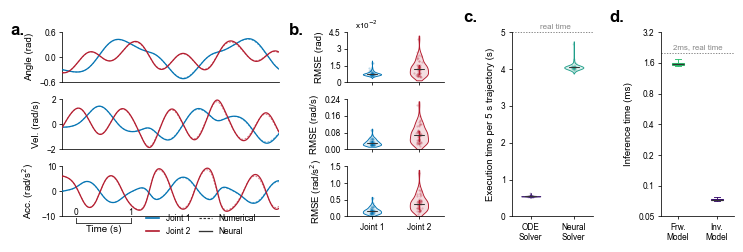

Data provenance:
  no_fake_data_generated = True
  demo_trajectory_index = 10
  trajectories = 50
  states_per_trajectory = 2500
  forward latency queries = 125000
  inverse latency queries = 10000
Latency summary:
          measurement      n   min_ms    q1_ms  median_ms    q3_ms   p99_ms    max_ms
forward_neural_solver 125000 1.447791 1.521958   1.542375 1.587500 1.907837 60.592334
    inverse_model_16k  10000 0.068417 0.072500   0.073333 0.074208 0.087043  0.402875


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# -----------------------------------------------------------------------------
# Load packaged data. FIG5.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG5.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG5")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG5.zip or FIG5 in the current folder. "
        "Place the data archive in the same folder as FIG5.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    with archive.open("fig5_arrays.npz") as npz_file:
        packaged = np.load(npz_file)
        arrays = {name: packaged[name] for name in packaged.files if name != "metadata_json"}
    rmse_table = pd.read_csv(archive.open("fig5_rmse_values.csv"))
    timing_table = pd.read_csv(archive.open("fig5_trajectory_timing.csv"))
    latency_table = pd.read_csv(archive.open("fig5_latency_values.csv"))
    latency_summary = pd.read_csv(archive.open("fig5_latency_summary.csv"))
    demo_table = pd.read_csv(archive.open("fig5_demo_trajectory.csv"))
    metadata = json.load(archive.open("fig5_metadata.json"))

# Named arrays used by the figure.
time_s = arrays["time_s"]
true_q = arrays["numerical_position_rad"]
pred_q = arrays["neural_position_rad"]
true_dq = arrays["numerical_velocity_rad_s"]
pred_dq = arrays["neural_velocity_rad_s"]
true_ddq = arrays["numerical_acceleration_rad_s2"]
pred_ddq = arrays["neural_acceleration_rad_s2"]
rmse_pos = arrays["position_rmse_rad"]
rmse_vel = arrays["velocity_rmse_rad_s"]
rmse_acc = arrays["acceleration_rmse_rad_s2"]
times_ode = arrays["trajectory_time_ode_s"]
times_neural = arrays["trajectory_time_neural_solver_s"]
forward_latency_ms = arrays["forward_latency_ms"]
inverse_latency_ms = arrays["inverse_latency_16k_ms"]
demo_idx = int(metadata["demo_trajectory_index"])
trajectory_real_time_s = float(metadata["trajectory_real_time_threshold_s"])
forward_real_time_ms = float(metadata["forward_real_time_threshold_ms"])

# -----------------------------------------------------------------------------
# Style and helpers.
# -----------------------------------------------------------------------------
BLUE = "#0072B2"
RED = "#B2182B"
NEUTRAL = "#333333"
LIGHT_NEUTRAL = "#8A8A8A"
ODE_COLOR = "#482878"
NEURAL_COLOR = "#1F9E89"
FORWARD_COLOR = "#2DBF6E"
INVERSE_COLOR = "#3B0F70"
JOINT_COLORS = [BLUE, RED]
rng = np.random.default_rng(23)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", direction="out", length=2.4, width=0.55, pad=2)
    ax.tick_params(axis="both", which="minor", direction="out", length=1.5, width=0.45)
    ax.grid(False)


def add_panel_label(ax, label, x=-0.24, y=1.16):
    ax.text(x, y, label, transform=ax.transAxes, ha="left", va="top",
            fontsize=12, fontweight="bold", color="black", clip_on=False)


def plot_point_series(ax, x_values, y_values, color, markersize=1.6, alpha=0.28, zorder=3):
    # Individual plot calls keep points editable as separate vector markers.
    for x_value, y_value in zip(np.asarray(x_values), np.asarray(y_values)):
        ax.plot([float(x_value)], [float(y_value)], marker="o", linestyle="None",
                markersize=markersize, markerfacecolor=color, markeredgecolor="none",
                alpha=alpha, zorder=zorder, rasterized=False)


def draw_distribution(ax, values, position, color, width=0.18, point_jitter=0.025,
                      point_size=1.7, point_alpha=0.28, envelope_alpha=0.14,
                      line_width=0.65):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 2:
        return
    y_min, y_max = float(values.min()), float(values.max())
    pad = max((y_max - y_min) * 0.08, max(abs(y_max), 1.0) * 0.002)
    y_grid = np.linspace(max(0.0, y_min - pad), y_max + pad, 180)
    try:
        density = gaussian_kde(values)(y_grid)
    except Exception:
        density = np.ones_like(y_grid)
    density = density / density.max() * width if density.max() > 0 else np.zeros_like(y_grid)
    ax.fill_betweenx(y_grid, position - density, position + density,
                     facecolor=mpl.colors.to_rgba(color, envelope_alpha),
                     edgecolor=color, linewidth=line_width, zorder=1)

    jitter = rng.normal(0.0, point_jitter, size=values.size)
    plot_point_series(ax, position + jitter, values, color,
                      markersize=point_size, alpha=point_alpha, zorder=2)

    q1, median, q3 = np.percentile(values, [25, 50, 75])
    ax.plot([position, position], [q1, q3], color=color, linewidth=1.0,
            solid_capstyle="round", zorder=4)
    ax.plot([position - width * 0.55, position + width * 0.55], [median, median],
            color=NEUTRAL, linewidth=0.75, solid_capstyle="round", zorder=5)


def plot_rollout_axis(ax, true_values, pred_values, ylabel, ylim, yticks):
    trace = slice(None, None, 4)
    t_trace = time_s[trace]
    for joint_idx, color in enumerate(JOINT_COLORS):
        ax.plot(t_trace, true_values[demo_idx, trace, joint_idx], color=color,
                linestyle=(0, (2.0, 1.45)), linewidth=0.70, alpha=0.58,
                solid_capstyle="round", zorder=2)
        ax.plot(t_trace, pred_values[demo_idx, trace, joint_idx], color=color,
                linestyle="-", linewidth=0.92, alpha=0.97,
                solid_capstyle="round", zorder=3)
    ax.set_xlim(float(time_s.min()), float(time_s.max()))
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    style_axis(ax)


def plot_rmse_axis(ax, values, ylabel, ylim, yticks, scale_note=None):
    positions = [1.0, 1.72]
    draw_distribution(ax, values[:, 0], positions[0], BLUE, width=0.14, point_jitter=0.018,
                      point_size=1.55, point_alpha=0.25)
    draw_distribution(ax, values[:, 1], positions[1], RED, width=0.14, point_jitter=0.018,
                      point_size=1.55, point_alpha=0.25)
    ax.set_xlim(0.62, 2.10)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_xticks(positions)
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel)
    if scale_note:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value / 1e-2:g}"))
        ax.text(0.08, 1.02, scale_note, transform=ax.transAxes, ha="left", va="bottom", fontsize=5.8)
    style_axis(ax)


def draw_box(ax, values_by_group, positions, colors, widths=0.22, whis=(5, 95), showfliers=False):
    bp = ax.boxplot(values_by_group, positions=positions, widths=widths, patch_artist=True,
                    manage_ticks=False, whis=whis, showfliers=showfliers)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(mpl.colors.to_rgba(color, 0.16))
        patch.set_edgecolor(color)
        patch.set_linewidth(0.75)
    for median in bp["medians"]:
        median.set_color(NEUTRAL)
        median.set_linewidth(0.85)
    for whisker, color in zip(bp["whiskers"], np.repeat(colors, 2)):
        whisker.set_color(color)
        whisker.set_linewidth(0.65)
    for cap, color in zip(bp["caps"], np.repeat(colors, 2)):
        cap.set_color(color)
        cap.set_linewidth(0.65)
    return bp

# -----------------------------------------------------------------------------
# Figure layout.
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(7.20, 2.35), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=3,
    ncols=4,
    width_ratios=[3.15, 1.40, 1.18, 1.06],
    height_ratios=[1.0, 1.0, 1.0],
    left=0.055,
    right=0.988,
    top=0.965,
    bottom=0.18,
    wspace=0.58,
    hspace=0.33,
)

ax_a1 = fig.add_subplot(gs[0, 0])
ax_a2 = fig.add_subplot(gs[1, 0], sharex=ax_a1)
ax_a3 = fig.add_subplot(gs[2, 0], sharex=ax_a1)
ax_b1 = fig.add_subplot(gs[0, 1])
ax_b2 = fig.add_subplot(gs[1, 1], sharex=ax_b1)
ax_b3 = fig.add_subplot(gs[2, 1], sharex=ax_b1)
ax_c = fig.add_subplot(gs[:, 2])
ax_d = fig.add_subplot(gs[:, 3])

plot_rollout_axis(ax_a1, true_q, pred_q, "Angle (rad)", (-0.6, 0.6), [-0.6, 0.0, 0.6])
plot_rollout_axis(ax_a2, true_dq, pred_dq, "Vel. (rad/s)", (-2.0, 2.0), [-2.0, 0.0, 2.0])
plot_rollout_axis(ax_a3, true_ddq, pred_ddq, "Acc. (rad/s$^2$)", (-10.0, 10.0), [-10.0, 0.0, 10.0])
add_panel_label(ax_a1, "a.", x=-0.24, y=1.18)

# A 1-second scale bar for panel a.
y_bar = -0.126
x0, x1 = 0.065, 0.315
ax_a3.plot([x0, x1], [y_bar, y_bar], transform=ax_a3.transAxes, color=NEUTRAL,
           linewidth=0.65, clip_on=False)
ax_a3.plot([x0, x0], [y_bar, y_bar + 0.10], transform=ax_a3.transAxes,
           color=NEUTRAL, linewidth=0.65, clip_on=False)
ax_a3.plot([x1, x1], [y_bar, y_bar + 0.10], transform=ax_a3.transAxes,
           color=NEUTRAL, linewidth=0.65, clip_on=False)
ax_a3.text(x0, y_bar + 0.115, "0", transform=ax_a3.transAxes, ha="center", va="bottom", fontsize=6)
ax_a3.text(x1, y_bar + 0.115, "1", transform=ax_a3.transAxes, ha="center", va="bottom", fontsize=6)
ax_a3.text((x0 + x1) / 2, y_bar - 0.05, "Time (s)", transform=ax_a3.transAxes,
           ha="center", va="top", fontsize=7)

legend_handles = [
    Line2D([0], [0], color=BLUE, linewidth=1.2, label="Joint 1"),
    Line2D([0], [0], color=RED, linewidth=1.2, label="Joint 2"),
    Line2D([0], [0], color=NEUTRAL, linewidth=0.85, linestyle=(0, (2.0, 1.45)), label="Numerical"),
    Line2D([0], [0], color=NEUTRAL, linewidth=0.95, linestyle="-", label="Neural"),
]
ax_a3.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.64, -0.45),
             ncol=2, frameon=False, handlelength=1.6, columnspacing=1.0, borderaxespad=0.0)

plot_rmse_axis(ax_b1, rmse_pos, "RMSE (rad)", (0.0, 0.045), [0.0, 0.015, 0.030, 0.045], "x10$^{-2}$")
plot_rmse_axis(ax_b2, rmse_vel, "RMSE (rad/s)", (0.0, 0.24), [0.0, 0.08, 0.16, 0.24])
plot_rmse_axis(ax_b3, rmse_acc, "RMSE (rad/s$^2$)", (0.0, 1.5), [0.0, 0.5, 1.0, 1.5])
ax_b3.set_xticklabels(["Joint 1", "Joint 2"])
for upper_rmse_ax in (ax_b1, ax_b2):
    upper_rmse_ax.tick_params(labelbottom=False)
add_panel_label(ax_b1, "b.", x=-0.60, y=1.19)

# Panel c: trajectory timing.
positions_c = [1.0, 1.72]
draw_distribution(ax_c, times_ode, positions_c[0], ODE_COLOR, width=0.16, point_jitter=0.018,
                  point_size=1.45, point_alpha=0.20, envelope_alpha=0.13)
draw_distribution(ax_c, times_neural, positions_c[1], NEURAL_COLOR, width=0.16, point_jitter=0.018,
                  point_size=1.45, point_alpha=0.20, envelope_alpha=0.16)
ax_c.axhline(trajectory_real_time_s, color=LIGHT_NEUTRAL, linewidth=0.70,
             linestyle=(0, (1.4, 1.4)), zorder=0)
ax_c.text(1.42, trajectory_real_time_s + 0.06, "real time", ha="center", va="bottom",
          fontsize=5.8, color=LIGHT_NEUTRAL)
ax_c.set_xlim(0.68, 2.04)
ax_c.set_ylim(0.0, 5.0)
ax_c.set_yticks(np.arange(0, 5.1, 1.0))
ax_c.set_xticks(positions_c)
ax_c.set_xticklabels(["ODE\nSolver", "Neural\nSolver"])
ax_c.set_ylabel("Execution time per 5 s trajectory (s)")
style_axis(ax_c)
add_panel_label(ax_c, "c.", x=-0.60, y=1.12)

# Panel d: per-query latency, log scale.
forward_vals = forward_latency_ms[np.isfinite(forward_latency_ms) & (forward_latency_ms > 0)]
inverse_vals = inverse_latency_ms[np.isfinite(inverse_latency_ms) & (inverse_latency_ms > 0)]
positions_d = [1.0, 1.72]
draw_box(ax_d, [forward_vals, inverse_vals], positions_d, [FORWARD_COLOR, INVERSE_COLOR], widths=0.22, whis=(5, 95), showfliers=False)
ax_d.axhline(forward_real_time_ms, color=LIGHT_NEUTRAL, linewidth=0.70,
             linestyle=(0, (1.4, 1.4)), zorder=0)
ax_d.text(1.36, forward_real_time_ms * 1.04, "2ms, real time", ha="center", va="bottom",
          fontsize=5.7, color=LIGHT_NEUTRAL)
ax_d.set_yscale("log", base=2)
ax_d.set_ylim(0.05, 3.2)
y_ticks = [0.05, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2]
ax_d.set_yticks(y_ticks)
ax_d.set_yticklabels(["0.05", "0.1", "0.2", "0.4", "0.8", "1.6", "3.2"])
ax_d.set_xlim(0.68, 2.04)
ax_d.set_xticks(positions_d)
ax_d.set_xticklabels(["Frw.\nModel", "Inv.\nModel"])
ax_d.set_ylabel("Inference time (ms)")
style_axis(ax_d)
add_panel_label(ax_d, "d.", x=-0.70, y=1.12)

for ext in ["svg", "pdf", "png"]:
    path = Path(f"FIG5.{ext}")
    if ext == "png":
        fig.savefig(path, dpi=600, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    else:
        fig.savefig(path, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    print(f"Saved {path.resolve()}")

plt.show()

print("Data provenance:")
print(f"  no_fake_data_generated = {metadata['no_fake_data_generated']}")
print(f"  demo_trajectory_index = {demo_idx}")
print(f"  trajectories = {metadata['num_trajectories']}")
print(f"  states_per_trajectory = {metadata['states_per_trajectory']}")
print(f"  forward latency queries = {forward_vals.size}")
print(f"  inverse latency queries = {inverse_vals.size}")
print("Latency summary:")
print(latency_summary.to_string(index=False))